In [2]:
!pip install statsmodels prophet xgboost tensorflow scikit-learn -q

Train: 192 months  |  Test: 81 months
Train mean=37.2  std=13.0
Test  mean=33.2  std=13.2


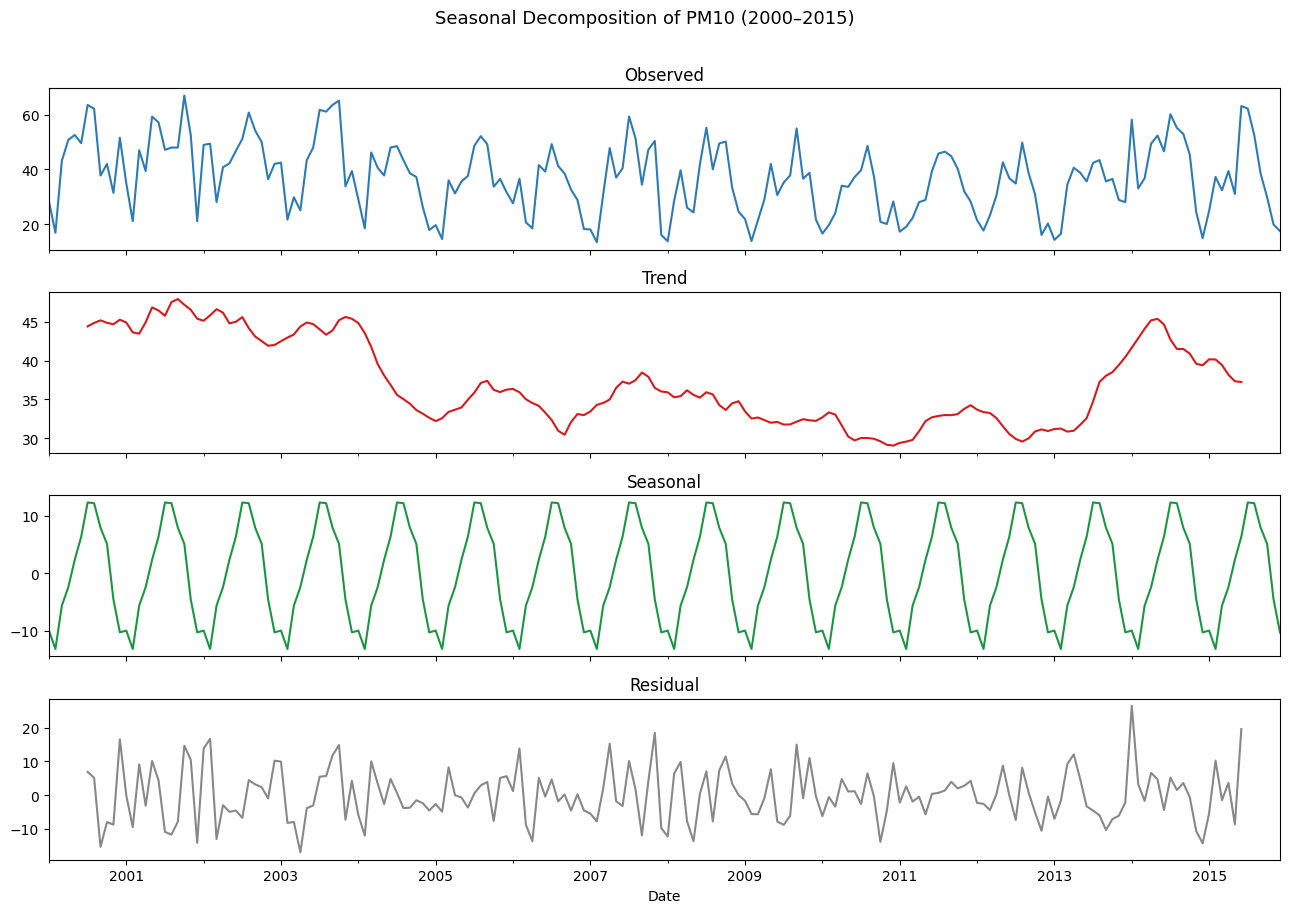

Saved: 01_decomposition.png

========== STATIONARITY TESTS ==========
  Original                            ADF=-1.981  p=0.2952  → NON-STATIONARY ✗
  Seasonal diff (lag-12)              ADF=-5.968  p=0.0000  → STATIONARY ✓
  Seasonal + regular diff             ADF=-5.529  p=0.0000  → STATIONARY ✓


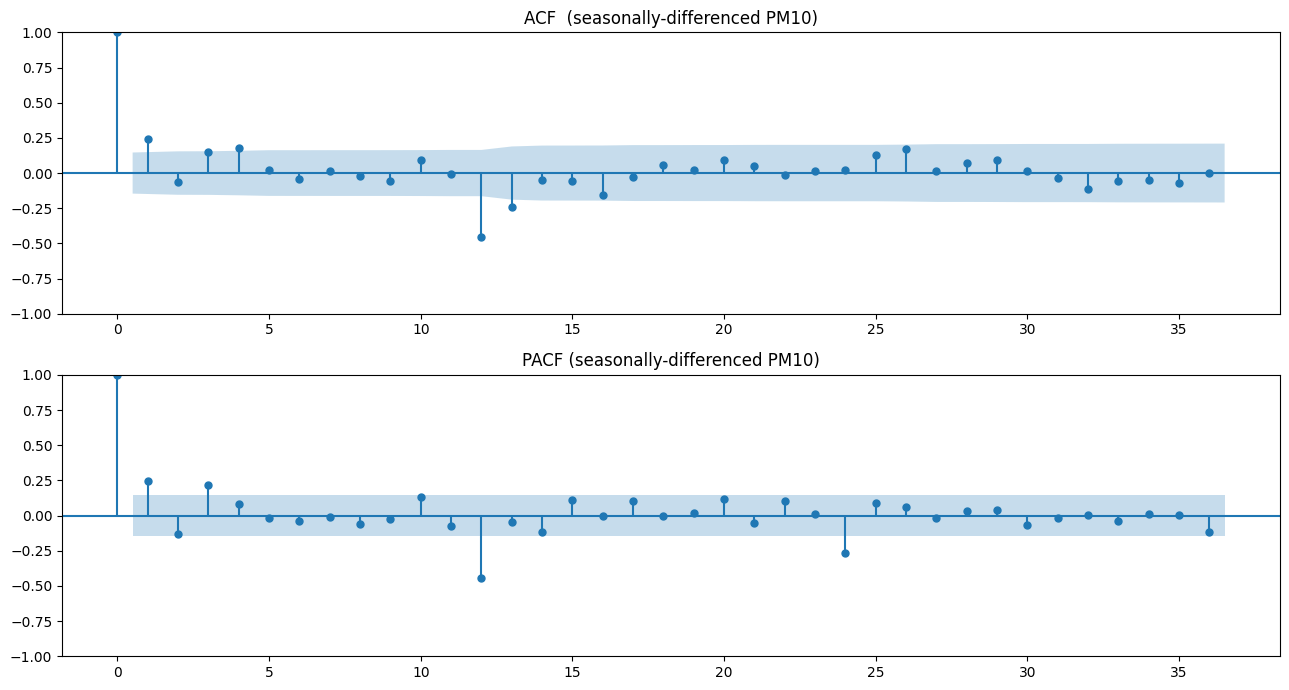

Saved: 02_acf_pacf.png
Interpretation: strong spikes at lag 12 in both plots → SARIMA seasonal MA/AR terms needed

========== SARIMA GRID SEARCH ==========
  SARIMA(1,0,0)(1,1,0,12)                     AIC=  1255.2  RMSE= 15.30  R²=-0.358
  SARIMA(0,0,1)(0,1,1,12)                     AIC=  1215.7  RMSE= 11.07  R²=0.289
  SARIMA(1,0,1)(1,1,0,12)                     AIC=  1254.4  RMSE= 15.37  R²=-0.371
  SARIMA(1,0,1)(0,1,1,12)                     AIC=  1212.6  RMSE=  9.94  R²=0.427
  SARIMA(1,0,1)(1,1,1,12)                     AIC=  1214.6  RMSE=  9.94  R²=0.427
  SARIMA(2,0,1)(1,1,1,12)                     AIC=  1218.9  RMSE= 10.76  R²=0.328
  SARIMA(1,0,2)(1,1,1,12)                     AIC=  1192.6  RMSE=  9.83  R²=0.440
  SARIMA(2,0,2)(1,1,1,12)                     AIC=  1194.5  RMSE=  9.84  R²=0.439
  SARIMA(0,0,0)(1,1,1,12)                     AIC=  1259.6  RMSE= 12.93  R²=0.030
  SARIMA(2,0,0)(0,1,1,12)                     AIC=  1228.4  RMSE= 10.59  R²=0.350

Best SARIMA (by RMSE)

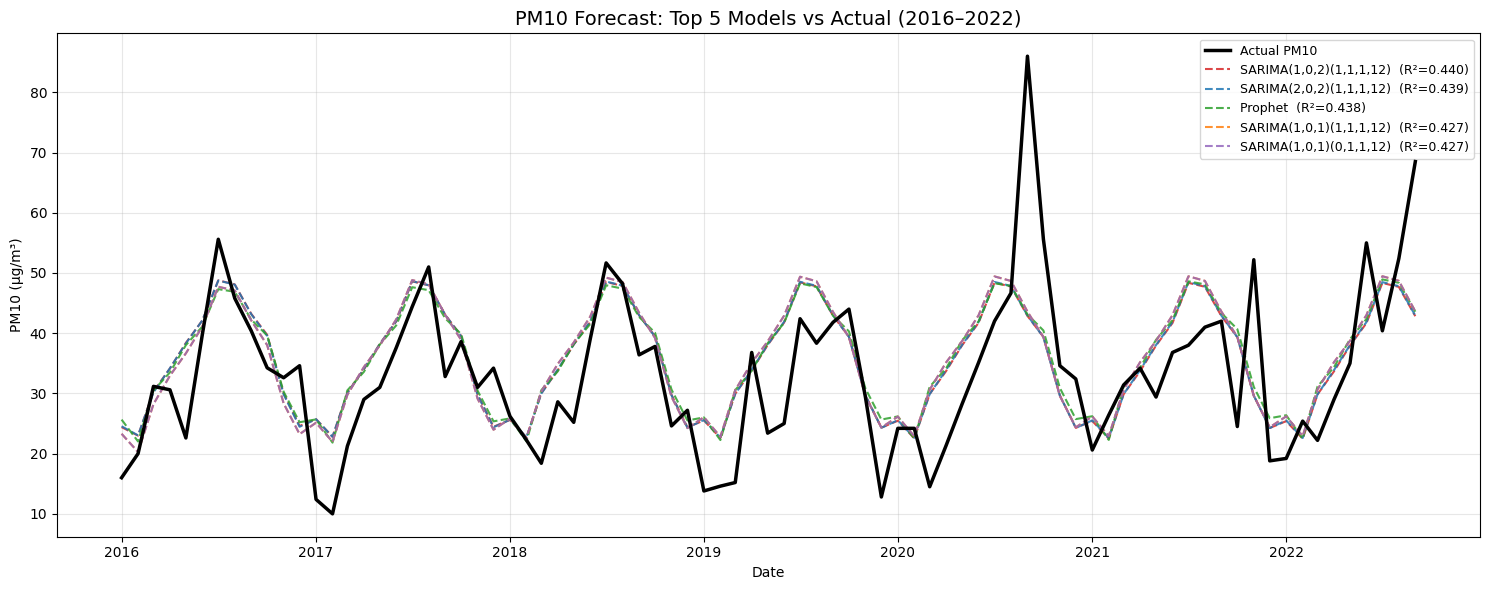

Saved: 03_forecast_comparison.png


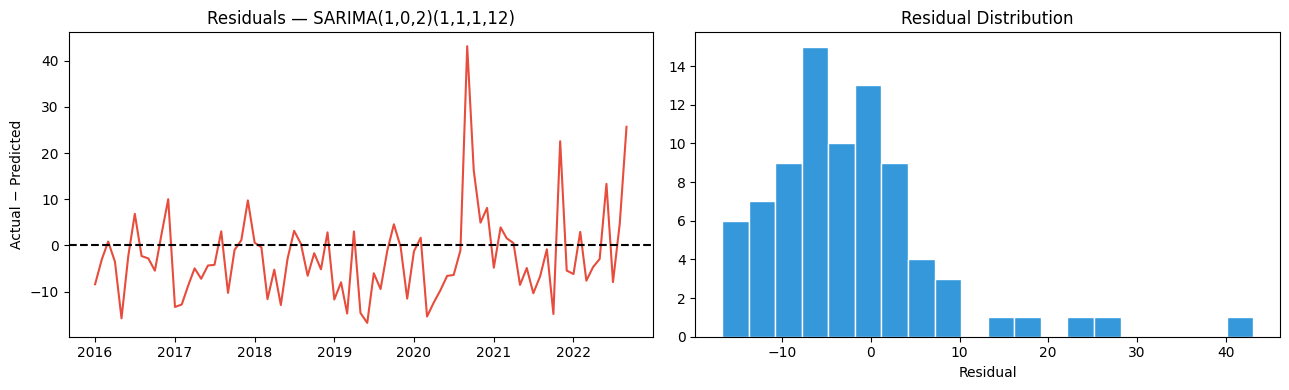

Saved: 04_residuals.png


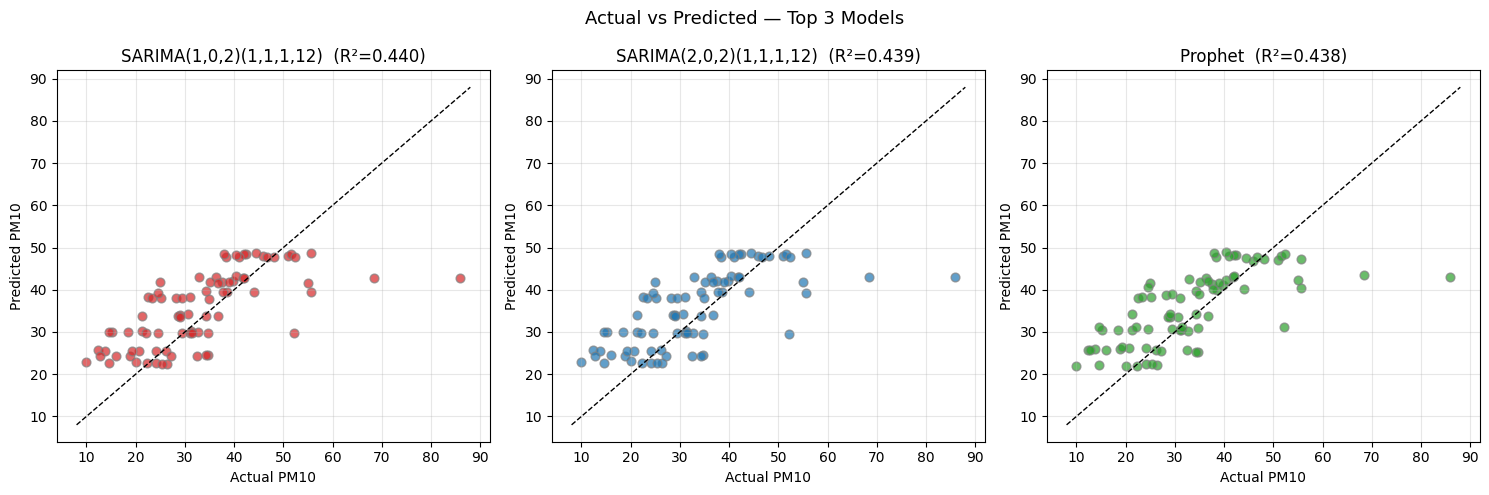

Saved: 05_actual_vs_predicted.png

FINAL RESULTS SUMMARY
                  Model    MAE   RMSE   MAPE      R2
SARIMA(1,0,2)(1,1,1,12)  7.260  9.825 27.061  0.4402
SARIMA(2,0,2)(1,1,1,12)  7.284  9.839 27.150  0.4386
                Prophet  7.273  9.845 27.455  0.4379
SARIMA(1,0,1)(1,1,1,12)  7.405  9.937 27.489  0.4274
SARIMA(1,0,1)(0,1,1,12)  7.407  9.939 27.494  0.4272
SARIMA(2,0,0)(0,1,1,12)  8.119 10.590 30.226  0.3497
SARIMA(2,0,1)(1,1,1,12)  8.297 10.762 30.893  0.3283
SARIMA(0,0,1)(0,1,1,12)  8.621 11.074 32.132  0.2888
                   LSTM  8.236 11.368 29.433  0.2506
                XGBoost  8.782 11.882 33.076  0.1813
SARIMA(0,0,0)(1,1,1,12) 10.651 12.934 40.228  0.0298
SARIMA(1,0,0)(1,1,0,12) 13.061 15.304 48.860 -0.3582
SARIMA(1,0,1)(1,1,0,12) 13.138 15.374 49.262 -0.3706

✓ Best model  : SARIMA(1,0,2)(1,1,1,12)
  RMSE        : 9.82 µg/m³
  MAE         : 7.26 µg/m³
  MAPE        : 27.1%
  R²          : 0.4402


In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

from prophet import Prophet
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================
# FILES  — adjust paths if running on Colab
# =====================================================
TRAIN_FILE = "/content/train_data_final.csv"
TEST_FILE  = "/content/test_data_final.csv"

# =====================================================
# LOAD DATA
# =====================================================
train = pd.read_csv(TRAIN_FILE)
test  = pd.read_csv(TEST_FILE)

train["Date"] = pd.to_datetime(train["Date"])
test["Date"]  = pd.to_datetime(test["Date"])

train = train.set_index("Date").asfreq("MS")
test  = test.set_index("Date").asfreq("MS")

y_train = train["PM10"]
y_test  = test["PM10"]

print(f"Train: {len(y_train)} months  |  Test: {len(y_test)} months")
print(f"Train mean={y_train.mean():.1f}  std={y_train.std():.1f}")
print(f"Test  mean={y_test.mean():.1f}  std={y_test.std():.1f}")

# =====================================================
# SEASONAL DECOMPOSITION  (visual insight)
# =====================================================
decomp = seasonal_decompose(y_train, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
decomp.observed.plot(ax=axes[0], title="Observed",   color="#2c7bb6")
decomp.trend.plot(   ax=axes[1], title="Trend",      color="#d7191c")
decomp.seasonal.plot(ax=axes[2], title="Seasonal",   color="#1a9641")
decomp.resid.plot(   ax=axes[3], title="Residual",   color="#888888")
plt.suptitle("Seasonal Decomposition of PM10 (2000–2015)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print("Saved: 01_decomposition.png")

# =====================================================
# STATIONARITY  —  unit-root tests
# =====================================================
print("\n========== STATIONARITY TESTS ==========")

def adf_summary(series, label):
    r = adfuller(series.dropna(), autolag="AIC")
    flag = "NON-STATIONARY ✗" if r[1] > 0.05 else "STATIONARY ✓"
    print(f"  {label:<35} ADF={r[0]:+.3f}  p={r[1]:.4f}  → {flag}")

adf_summary(y_train,                "Original")
adf_summary(y_train.diff(12),       "Seasonal diff (lag-12)")
adf_summary(y_train.diff(12).diff(),"Seasonal + regular diff")

# Series is non-stationary in levels but stationary after seasonal differencing
# ⇒ use d=0,D=1 in SARIMA (seasonal differencing handles it)

# =====================================================
# ACF / PACF  of seasonally-differenced series
# =====================================================
y_sdiff = y_train.diff(12).dropna()

fig, ax = plt.subplots(2, 1, figsize=(13, 7))
plot_acf( y_sdiff, lags=36, ax=ax[0], title="ACF  (seasonally-differenced PM10)")
plot_pacf(y_sdiff, lags=36, ax=ax[1], title="PACF (seasonally-differenced PM10)")
plt.tight_layout()
plt.show()
print("Saved: 02_acf_pacf.png")
print("Interpretation: strong spikes at lag 12 in both plots → SARIMA seasonal MA/AR terms needed")

# =====================================================
# SARIMA  — systematic grid search  (p,d,q)(P,D,Q,12)
# =====================================================
print("\n========== SARIMA GRID SEARCH ==========")

# d=0 (no regular diff needed once seasonal diff D=1 is applied)
# D=1 seasonal differencing
sarima_grid = [
    # (p,d,q)(P,D,Q)
    (1,0,0,1,1,0),
    (0,0,1,0,1,1),
    (1,0,1,1,1,0),
    (1,0,1,0,1,1),
    (1,0,1,1,1,1),
    (2,0,1,1,1,1),
    (1,0,2,1,1,1),
    (2,0,2,1,1,1),
    (0,0,0,1,1,1),
    (2,0,0,0,1,1),
]

sarima_results = []
sarima_models  = {}

for (p,d,q,P,D,Q) in sarima_grid:
    label = f"SARIMA({p},{d},{q})({P},{D},{Q},12)"
    try:
        m   = SARIMAX(y_train, order=(p,d,q),
                      seasonal_order=(P,D,Q,12),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
        fit = m.fit(disp=False)
        pred = fit.forecast(len(y_test))
        mae  = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        mape = np.mean(np.abs((y_test - pred) / y_test)) * 100
        r2   = r2_score(y_test, pred)
        sarima_results.append([label, mae, rmse, mape, r2, fit.aic])
        sarima_models[label] = pred
        print(f"  {label:<42}  AIC={fit.aic:8.1f}  RMSE={rmse:6.2f}  R²={r2:.3f}")
    except Exception as e:
        print(f"  {label:<42}  FAILED: {e}")

sarima_df = pd.DataFrame(sarima_results,
    columns=["Model","MAE","RMSE","MAPE","R2","AIC"])
best_sarima = sarima_df.sort_values("RMSE").iloc[0]["Model"]
print(f"\nBest SARIMA (by RMSE): {best_sarima}")

# =====================================================
# PROPHET  (with seasonality tuning)
# =====================================================
print("\n========== PROPHET ==========")

prophet_train = y_train.reset_index().rename(columns={"Date":"ds","PM10":"y"})

prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="multiplicative",   # better for skewed/heteroscedastic data
    changepoint_prior_scale=0.05,        # regularise trend changes
    seasonality_prior_scale=10.0
)
prophet.fit(prophet_train)

future   = prophet.make_future_dataframe(periods=len(y_test), freq="MS")
forecast = prophet.predict(future)
prophet_pred = forecast["yhat"].tail(len(y_test)).values

# =====================================================
# XGBOOST  — rich feature engineering
# =====================================================
print("\n========== XGBOOST ==========")

def make_xgb_features(series: pd.Series, n_lags=24) -> pd.DataFrame:
    df = series.to_frame(name="PM10")
    # lags
    for lag in range(1, n_lags + 1):
        df[f"lag_{lag}"] = df["PM10"].shift(lag)
    # rolling statistics
    for win in [3, 6, 12]:
        df[f"roll_mean_{win}"] = df["PM10"].shift(1).rolling(win).mean()
        df[f"roll_std_{win}"]  = df["PM10"].shift(1).rolling(win).std()
        df[f"roll_max_{win}"]  = df["PM10"].shift(1).rolling(win).max()
        df[f"roll_min_{win}"]  = df["PM10"].shift(1).rolling(win).min()
    # calendar
    df["month"]      = df.index.month
    df["month_sin"]  = np.sin(2 * np.pi * df.index.month / 12)
    df["month_cos"]  = np.cos(2 * np.pi * df.index.month / 12)
    df["year"]       = df.index.year
    df["year_norm"]  = (df.index.year - 2000) / 22  # normalised year as trend proxy
    return df.dropna()

full_data = pd.concat([y_train, y_test])
feat_df   = make_xgb_features(full_data, n_lags=24)

# train / test split (no leakage — all features use shift(1) or lag>=1)
train_feat = feat_df.loc[y_train.index.intersection(feat_df.index)]
test_feat  = feat_df.loc[y_test.index.intersection(feat_df.index)]

X_train_xgb = train_feat.drop("PM10", axis=1)
y_train_xgb = train_feat["PM10"]
X_test_xgb  = test_feat.drop("PM10", axis=1)

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)
xgb.fit(X_train_xgb, y_train_xgb,
        eval_set=[(X_train_xgb, y_train_xgb)],
        verbose=False)

# For direct multi-step: use actual history + predicted values recursively
history_full = list(y_train.values)
xgb_pred = []

for i in range(len(y_test)):
    row = pd.Series({"PM10": np.nan}, dtype=float)
    # build feature vector from current history
    tmp = pd.Series(history_full, index=pd.date_range(
        y_train.index[0], periods=len(history_full), freq="MS"))
    tmp_feat = make_xgb_features(tmp, n_lags=24)
    if len(tmp_feat) == 0:
        xgb_pred.append(np.nan)
        history_full.append(np.nan)
        continue
    x_row = tmp_feat.iloc[[-1]].drop("PM10", axis=1)
    p = xgb.predict(x_row)[0]
    xgb_pred.append(p)
    history_full.append(p)

xgb_pred = np.array(xgb_pred)

# =====================================================
# LSTM  — improved architecture + features
# =====================================================
print("\n========== LSTM ==========")

tf.random.set_seed(42)
np.random.seed(42)

LOOKBACK = 24   # 2 years of monthly history

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(y_train.values.reshape(-1, 1))

# Build supervised dataset
def make_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_lstm, y_lstm = make_sequences(scaled_train, LOOKBACK)
X_lstm = X_lstm.reshape(X_lstm.shape[0], X_lstm.shape[1], 1)

lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])
lstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="huber")

es = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)

lstm.fit(X_lstm, y_lstm,
         epochs=200, batch_size=16,
         validation_split=0.15,
         callbacks=[es], verbose=0)

# Recursive forecast
window = list(scaled_train[-LOOKBACK:, 0])
lstm_pred = []
for _ in range(len(y_test)):
    x = np.array(window[-LOOKBACK:]).reshape(1, LOOKBACK, 1)
    p = lstm.predict(x, verbose=0)[0, 0]
    lstm_pred.append(p)
    window.append(p)

lstm_pred = scaler.inverse_transform(
    np.array(lstm_pred).reshape(-1, 1)
).flatten()

# =====================================================
# COLLECT ALL PREDICTIONS
# =====================================================
all_preds = {**sarima_models}
all_preds["Prophet"]  = prophet_pred
all_preds["XGBoost"]  = xgb_pred
all_preds["LSTM"]     = lstm_pred

# =====================================================
# EVALUATE ALL MODELS
# =====================================================
def evaluate(name, pred, actual):
    pred   = np.array(pred)
    actual = np.array(actual)
    mask   = ~np.isnan(pred)
    pred, actual = pred[mask], actual[mask]
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    r2   = r2_score(actual, pred)
    return [name, round(mae,3), round(rmse,3), round(mape,3), round(r2,4)]

rows = [evaluate(name, pred, y_test) for name, pred in all_preds.items()]
results = pd.DataFrame(rows, columns=["Model","MAE","RMSE","MAPE","R2"])
results = results.sort_values("RMSE").reset_index(drop=True)

print("\n========== MODEL COMPARISON ==========")
print(results.to_string(index=False))
best_model = results.iloc[0]["Model"]
print(f"\nBest Model: {best_model}")

# =====================================================
# FORECAST COMPARISON PLOT  (top 5 + actual)
# =====================================================
top5 = results["Model"].head(5).tolist()

colors = ["#d62728","#1f77b4","#2ca02c","#ff7f0e","#9467bd","#8c564b"]

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(y_test.index, y_test.values,
        color="black", linewidth=2.5, label="Actual PM10", zorder=10)

for i, model in enumerate(top5):
    pred = np.array(all_preds[model])
    ax.plot(y_test.index, pred,
            color=colors[i], linewidth=1.5, linestyle="--",
            label=f"{model}  (R²={results[results.Model==model].R2.values[0]:.3f})",
            alpha=0.85)

ax.set_title("PM10 Forecast: Top 5 Models vs Actual (2016–2022)", fontsize=14)
ax.set_xlabel("Date"); ax.set_ylabel("PM10 (µg/m³)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Saved: 03_forecast_comparison.png")

# =====================================================
# RESIDUAL DIAGNOSTICS  for best model
# =====================================================
best_pred = np.array(all_preds[best_model])
residuals = y_test.values - best_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(y_test.index, residuals, color="#e74c3c")
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_title(f"Residuals — {best_model}")
axes[0].set_ylabel("Actual − Predicted")

axes[1].hist(residuals, bins=20, color="#3498db", edgecolor="white")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()
print("Saved: 04_residuals.png")

# =====================================================
# SCATTER: Actual vs Predicted  (top 3 models)
# =====================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, model in enumerate(results["Model"].head(3)):
    pred = np.array(all_preds[model])
    r2   = results[results.Model == model].R2.values[0]
    axes[i].scatter(y_test.values, pred, alpha=0.7, color=colors[i], edgecolors="grey", s=40)
    lo, hi = y_test.min() - 2, y_test.max() + 2
    axes[i].plot([lo, hi], [lo, hi], "k--", linewidth=1)
    axes[i].set_title(f"{model}  (R²={r2:.3f})")
    axes[i].set_xlabel("Actual PM10")
    axes[i].set_ylabel("Predicted PM10")
    axes[i].grid(True, alpha=0.3)
plt.suptitle("Actual vs Predicted — Top 3 Models", fontsize=13)
plt.tight_layout()

plt.show()
print("Saved: 05_actual_vs_predicted.png")

# =====================================================
# PRINT FINAL SUMMARY
# =====================================================
print("\n" + "="*55)
print("FINAL RESULTS SUMMARY")
print("="*55)
print(results.to_string(index=False))
print(f"\n✓ Best model  : {best_model}")
print(f"  RMSE        : {results.iloc[0].RMSE:.2f} µg/m³")
print(f"  MAE         : {results.iloc[0].MAE:.2f} µg/m³")
print(f"  MAPE        : {results.iloc[0].MAPE:.1f}%")
print(f"  R²          : {results.iloc[0].R2:.4f}")
